# Facial Emotion Recognition - FERPlus Dataset

**Dataset:** 8 Emotions (Angry, Contempt, Disgust, Fear, Happy, Neutral, Sad, Surprise)

**Samples:**
- Train: 66,379
- Validation: 8,341
- Test: 3,579

**Models:**
1. Baseline CNN
2. Stronger CNN
3. EfficientNetB3 Phase 1 (Frozen)
4. EfficientNetB3 Phase 2 (Fine-tuned)

## 1. Environment Setup

In [1]:
import tensorflow as tf
import os

print("✅ TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("💻 GPUs:", gpus)
print("✅ GPU Available" if gpus else "⚠️ No GPU - Enable GPU in Runtime → Change runtime type")

✅ TensorFlow: 2.19.0
💻 GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU Available


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


## 3. Extract Dataset with Verification

In [3]:
import zipfile
import shutil
import time

# Paths
ZIP_PATH = '/content/drive/MyDrive/archive (1).zip'
EXTRACT_DIR = '/content/drive/MyDrive/FERPlus_extracted'

# Expected structure
EXPECTED_FOLDERS = ['train', 'validation', 'test']
EXPECTED_SAMPLES = {
    'train': 66379,
    'validation': 8341,
    'test': 3579
}

def count_images(directory):
    """Count all images in subdirectories"""
    total = 0
    for root, dirs, files in os.walk(directory):
        total += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return total

def verify_extraction():
    """Verify all data was extracted correctly"""
    print("\n" + "="*70)
    print("🔍 VERIFICATION")
    print("="*70)

    all_good = True

    for folder in EXPECTED_FOLDERS:
        folder_path = os.path.join(EXTRACT_DIR, folder)
        if os.path.exists(folder_path):
            count = count_images(folder_path)
            expected = EXPECTED_SAMPLES[folder]
            status = "✅" if count == expected else "⚠️"
            print(f"{status} {folder}: {count:,} images (expected {expected:,})")
            if count != expected:
                all_good = False
        else:
            print(f"❌ {folder}: MISSING!")
            all_good = False

    print("="*70)
    return all_good

# Check if already extracted and verified
if os.path.exists(EXTRACT_DIR):
    print("📂 Found existing extraction. Verifying...")
    if verify_extraction():
        print("\n✅ All data verified! Using existing extraction.")
        print("💡 Skipping extraction to save time.\n")
    else:
        print("\n⚠️ Incomplete extraction detected. Re-extracting...")
        shutil.rmtree(EXTRACT_DIR)
        os.makedirs(EXTRACT_DIR, exist_ok=True)

        print(f"\n📦 Extracting {ZIP_PATH}...")
        start = time.time()

        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            members = zip_ref.namelist()
            print(f"   Total files in zip: {len(members):,}")
            zip_ref.extractall(EXTRACT_DIR)

        print(f"\n✅ Extracted in {time.time()-start:.1f}s")
        verify_extraction()
else:
    print(f"📦 First time extraction...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    print(f"\n📦 Extracting {ZIP_PATH}...")
    print("⏱️  This will take a few minutes...\n")
    start = time.time()

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        members = zip_ref.namelist()
        print(f"   Total files in zip: {len(members):,}")
        zip_ref.extractall(EXTRACT_DIR)

    print(f"\n✅ Extracted in {time.time()-start:.1f}s")
    verify_extraction()

print(f"\n📁 Data location: {EXTRACT_DIR}")

📦 First time extraction...

📦 Extracting /content/drive/MyDrive/archive (1).zip...
⏱️  This will take a few minutes...

   Total files in zip: 78,293

✅ Extracted in 415.9s

🔍 VERIFICATION
✅ train: 66,379 images (expected 66,379)
✅ validation: 8,341 images (expected 8,341)
⚠️ test: 3,573 images (expected 3,579)

📁 Data location: /content/drive/MyDrive/FERPlus_extracted


## 4. Setup Paths

In [4]:
# Detect folder structure
if os.path.exists(os.path.join(EXTRACT_DIR, 'train')):
    BASE_DIR = EXTRACT_DIR
elif os.path.exists(os.path.join(EXTRACT_DIR, 'archive (1)', 'train')):
    BASE_DIR = os.path.join(EXTRACT_DIR, 'archive (1)')
else:
    # List what's actually there
    contents = os.listdir(EXTRACT_DIR)
    print(f"⚠️ Unexpected structure. Contents: {contents}")
    # Try to find train folder
    for item in contents:
        item_path = os.path.join(EXTRACT_DIR, item)
        if os.path.isdir(item_path) and os.path.exists(os.path.join(item_path, 'train')):
            BASE_DIR = item_path
            break
    else:
        BASE_DIR = EXTRACT_DIR

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
MODELS_DIR = '/content/drive/MyDrive/deep learning project/models'
os.makedirs(MODELS_DIR, exist_ok=True)

print("\n✅ Paths:")
print(f"   Train: {TRAIN_DIR}")
print(f"   Val: {VAL_DIR}")
print(f"   Test: {TEST_DIR}")
print(f"   Models: {MODELS_DIR}")

# Final verification
if all(os.path.exists(p) for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]):
    print(f"\n📁 Emotions: {sorted(os.listdir(TRAIN_DIR))}")
    print("✅ All folders verified!")
else:
    print("\n❌ ERROR: Some folders missing!")
    for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
        print(f"   {name}: {'✅' if os.path.exists(path) else '❌'}")


✅ Paths:
   Train: /content/drive/MyDrive/FERPlus_extracted/train
   Val: /content/drive/MyDrive/FERPlus_extracted/validation
   Test: /content/drive/MyDrive/FERPlus_extracted/test
   Models: /content/drive/MyDrive/deep learning project/models

📁 Emotions: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']
✅ All folders verified!


## 5. Dataset Distribution


📊 FERPLUS DATASET DISTRIBUTION

 Emotion  Train  Validation  Test  Total
   angry   8000        1000   322   9322
contempt   8000        1000    30   9030
 disgust   8000        1000    21   9021
    fear   8000        1000    98   9098
   happy   8000        1000   929   9929
 neutral  10379        1341  1274  12994
     sad   8000        1000   449   9449
 suprise   8000        1000   450   9450

TOTAL TRAIN:      66,379
TOTAL VALIDATION: 8,341
TOTAL TEST:       3,573
GRAND TOTAL:      78,293


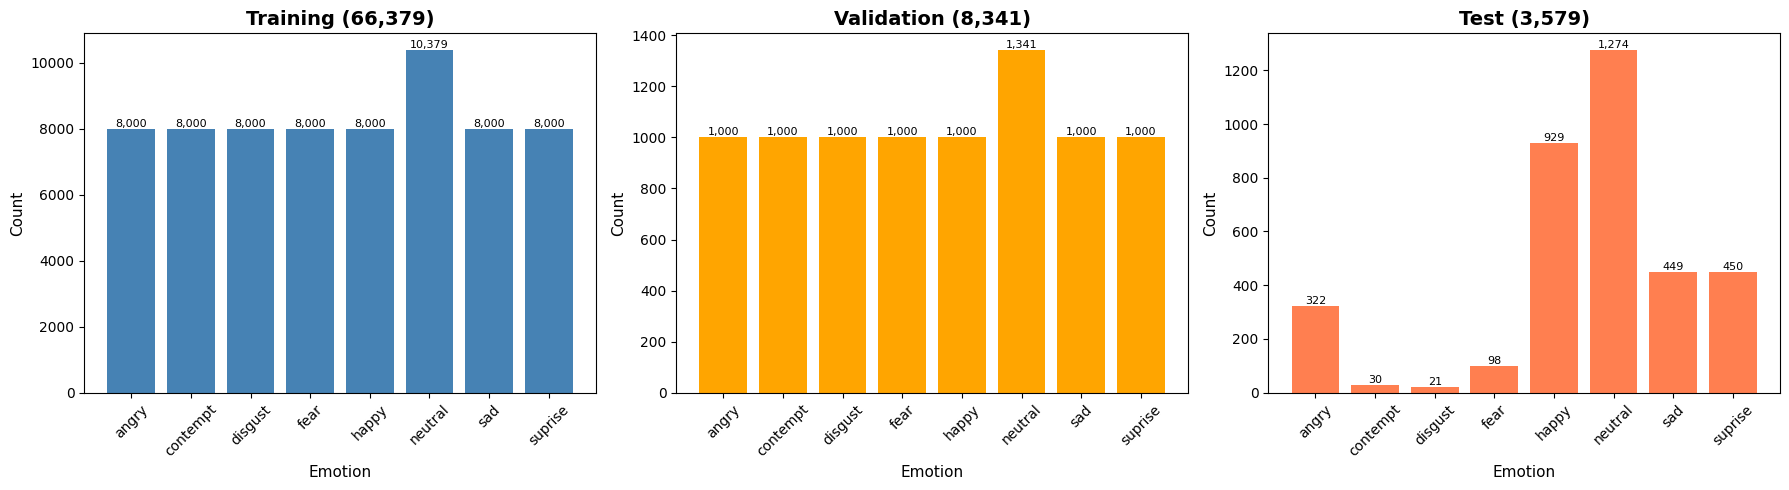


✅ Saved: /content/drive/MyDrive/deep learning project/models/dataset_distribution.png


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

def count_per_class(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([f for f in os.listdir(class_path)
                                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return counts

train_counts = count_per_class(TRAIN_DIR)
val_counts = count_per_class(VAL_DIR)
test_counts = count_per_class(TEST_DIR)

df = pd.DataFrame({
    'Emotion': list(train_counts.keys()),
    'Train': list(train_counts.values()),
    'Validation': list(val_counts.values()),
    'Test': list(test_counts.values())
})
df['Total'] = df['Train'] + df['Validation'] + df['Test']

print("\n" + "="*70)
print("📊 FERPLUS DATASET DISTRIBUTION")
print("="*70 + "\n")
print(df.to_string(index=False))
print(f"\n{'='*70}")
print(f"TOTAL TRAIN:      {sum(train_counts.values()):,}")
print(f"TOTAL VALIDATION: {sum(val_counts.values()):,}")
print(f"TOTAL TEST:       {sum(test_counts.values()):,}")
print(f"GRAND TOTAL:      {df['Total'].sum():,}")
print("="*70)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, counts, title, color in zip(
    axes, [train_counts, val_counts, test_counts],
    ['Training (66,379)', 'Validation (8,341)', 'Test (3,579)'],
    ['steelblue', 'orange', 'coral']
):
    ax.bar(counts.keys(), counts.values(), color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    for i, (emotion, count) in enumerate(counts.items()):
        ax.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'dataset_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: {os.path.join(MODELS_DIR, 'dataset_distribution.png')}")

## 6. Data Preprocessing

In [6]:
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\n✅ Classes ({num_classes}):", class_names)

train_ds_prep = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_prep = val_ds.cache().prefetch(AUTOTUNE)
test_ds_prep = test_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

normalization_layer = layers.Rescaling(1./255)
print("✅ Data pipeline ready")

Found 66379 files belonging to 8 classes.
Found 8341 files belonging to 8 classes.
Found 3573 files belonging to 8 classes.

✅ Classes (8): ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']
✅ Data pipeline ready


## 7. MODEL 1: Baseline CNN

In [7]:
from tensorflow.keras import models, regularizers

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = normalization_layer(x)

x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

baseline_cnn = models.Model(inputs, outputs, name="baseline_cnn")
print("✅ Baseline CNN")
baseline_cnn.summary()

✅ Baseline CNN


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,704 (50.50 MB)

 Trainable params: 13,236,744 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
from tensorflow.keras import optimizers, callbacks
import pickle

baseline_cnn.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_path = os.path.join(MODELS_DIR, "baseline_cnn.keras")
baseline_cb = [
    callbacks.ModelCheckpoint(baseline_path, monitor="val_loss", save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
]

print("🚀 Training Baseline CNN...\n")
hist_baseline = baseline_cnn.fit(
    train_ds_prep, validation_data=val_ds_prep, epochs=25, callbacks=baseline_cb
)

baseline_cnn.save(baseline_path)
with open(os.path.join(MODELS_DIR, 'baseline_history.pkl'), 'wb') as f:
    pickle.dump(hist_baseline.history, f)
print(f"\n✅ Saved: {baseline_path}")

🚀 Training Baseline CNN...

Epoch 1/25
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1907 - loss: 2.2602
Epoch 1: val_loss improved from inf to 1.81036, saving model to /content/drive/MyDrive/deep learning project/models/baseline_cnn.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 186s 64ms/step - accuracy: 0.1907 - loss: 2.2600 - val_accuracy: 0.3510 - val_loss: 1.8104 - learning_rate: 1.0000e-04
Epoch 2/25
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2681 - loss: 1.9352
Epoch 2: val_loss improved from 1.81036 to 1.72595, saving model to /content/drive/MyDrive/deep learning project/models/baseline_cnn.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 56s 54ms/step - accuracy: 0.2681 - loss: 1.9351 - val_accuracy: 0.3561 - val_loss: 1.7259 - learning_rate: 1.0000e-04
Epoch 3/25
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3148 - loss: 1.7959
Epoch 3: val_loss improved from 1.72595 to 1.60525, saving model to /content/drive/MyDrive/deep learning project/models/baseline_cnn

📊 BASELINE CNN - DETAILED RESULTS

1️⃣ TRAINING HISTORY
----------------------------------------------------------------------


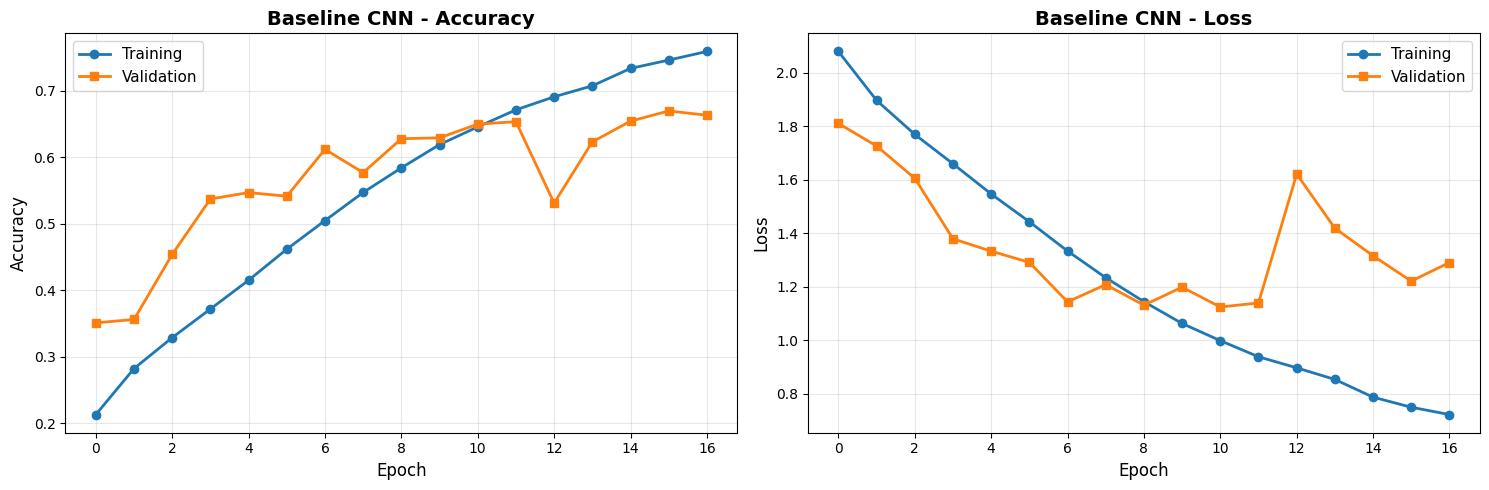


📈 Final Training Metrics (Epoch 17):
   Training Accuracy:   0.7586
   Training Loss:       0.7227
   Validation Accuracy: 0.6629
   Validation Loss:     1.2908

🏆 Best Validation Accuracy: 0.6693 (Epoch 16)


2️⃣ TEST SET EVALUATION
----------------------------------------------------------------------
🔄 Evaluating on test set...

✅ Test Accuracy: 0.6695 (66.95%)


3️⃣ CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       angry     0.5493    0.5714    0.5601       322
    contempt     0.1370    0.3333    0.1942        30
     disgust     0.2955    0.6190    0.4000        21
        fear     0.3750    0.4286    0.4000        98
       happy     0.8646    0.7492    0.8028       929
     neutral     0.7097    0.7253    0.7174      1274
         sad     0.4073    0.3964    0.4018       449
     suprise     0.7419    0.7667    0.7541       450

    accuracy                         0.6695  

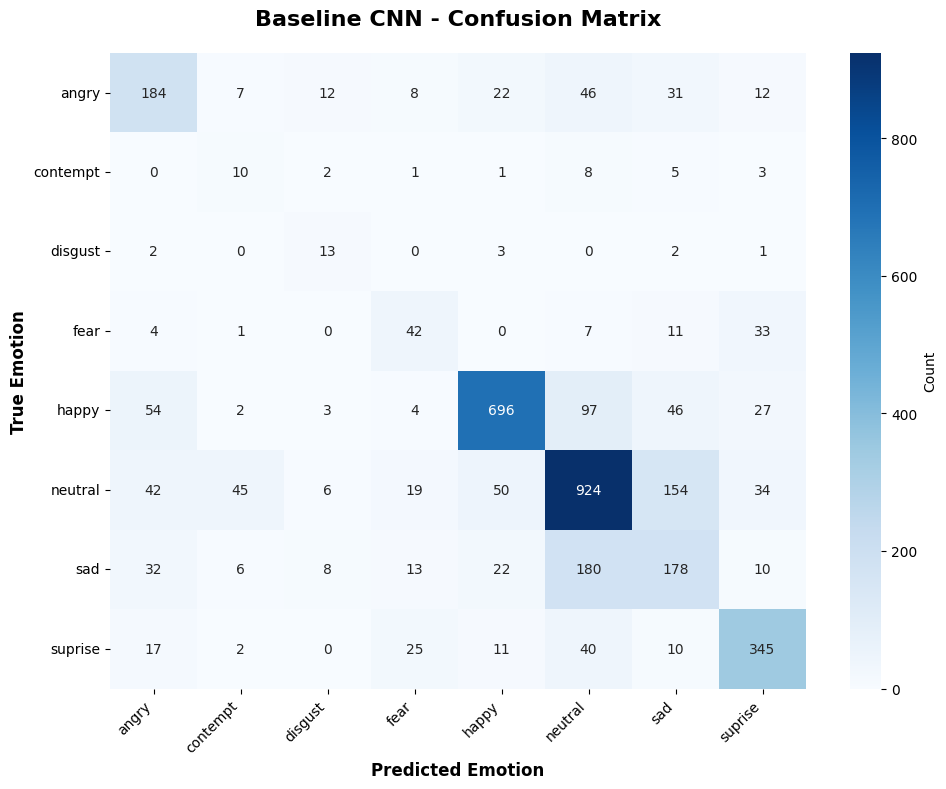


5️⃣ PER-CLASS ACCURACY
----------------------------------------------------------------------
   angry       : 0.5714 (57.14%) - 184/322 correct
   contempt    : 0.3333 (33.33%) - 10/30 correct
   disgust     : 0.6190 (61.90%) - 13/21 correct
   fear        : 0.4286 (42.86%) - 42/98 correct
   happy       : 0.7492 (74.92%) - 696/929 correct
   neutral     : 0.7253 (72.53%) - 924/1274 correct
   sad         : 0.3964 (39.64%) - 178/449 correct
   suprise     : 0.7667 (76.67%) - 345/450 correct


📋 SUMMARY
✅ Model: Baseline CNN
✅ Total Epochs: 17
✅ Final Training Accuracy: 0.7586
✅ Final Validation Accuracy: 0.6629
✅ Test Accuracy: 0.6695
✅ Number of Classes: 8
✅ Test Samples: 3,573


In [9]:
# ============================================================================
# VIEW BASELINE CNN RESULTS
# Add this as a new cell in your Colab notebook after Model 1 training
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("="*70)
print("📊 BASELINE CNN - DETAILED RESULTS")
print("="*70)

# 1. TRAINING HISTORY
print("\n1️⃣ TRAINING HISTORY")
print("-"*70)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist_baseline.history['accuracy'], label='Training', linewidth=2, marker='o')
axes[0].plot(hist_baseline.history['val_accuracy'], label='Validation', linewidth=2, marker='s')
axes[0].set_title('Baseline CNN - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(hist_baseline.history['loss'], label='Training', linewidth=2, marker='o')
axes[1].plot(hist_baseline.history['val_loss'], label='Validation', linewidth=2, marker='s')
axes[1].set_title('Baseline CNN - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_epoch = len(hist_baseline.history['accuracy']) - 1
print(f"\n📈 Final Training Metrics (Epoch {final_epoch + 1}):")
print(f"   Training Accuracy:   {hist_baseline.history['accuracy'][-1]:.4f}")
print(f"   Training Loss:       {hist_baseline.history['loss'][-1]:.4f}")
print(f"   Validation Accuracy: {hist_baseline.history['val_accuracy'][-1]:.4f}")
print(f"   Validation Loss:     {hist_baseline.history['val_loss'][-1]:.4f}")

# Best metrics
best_val_acc_idx = np.argmax(hist_baseline.history['val_accuracy'])
print(f"\n🏆 Best Validation Accuracy: {hist_baseline.history['val_accuracy'][best_val_acc_idx]:.4f} (Epoch {best_val_acc_idx + 1})")

# 2. TEST SET EVALUATION
print("\n\n2️⃣ TEST SET EVALUATION")
print("-"*70)

# Get predictions on test set
print("🔄 Evaluating on test set...")
y_true = []
y_pred = []

for images, labels in test_ds_prep:
    predictions = baseline_cnn.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Test accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. CLASSIFICATION REPORT
print("\n\n3️⃣ CLASSIFICATION REPORT")
print("-"*70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 4. CONFUSION MATRIX
print("\n4️⃣ CONFUSION MATRIX")
print("-"*70)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Baseline CNN - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. PER-CLASS ACCURACY
print("\n5️⃣ PER-CLASS ACCURACY")
print("-"*70)

class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, (emotion, acc) in enumerate(zip(class_names, class_accuracy)):
    total = cm.sum(axis=1)[i]
    correct = cm.diagonal()[i]
    print(f"   {emotion:12s}: {acc:.4f} ({acc*100:5.2f}%) - {correct}/{total} correct")

# 6. SUMMARY
print("\n\n" + "="*70)
print("📋 SUMMARY")
print("="*70)
print(f"✅ Model: Baseline CNN")
print(f"✅ Total Epochs: {len(hist_baseline.history['accuracy'])}")
print(f"✅ Final Training Accuracy: {hist_baseline.history['accuracy'][-1]:.4f}")
print(f"✅ Final Validation Accuracy: {hist_baseline.history['val_accuracy'][-1]:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of Classes: {len(class_names)}")
print(f"✅ Test Samples: {len(y_true):,}")
print("="*70)

## 8. MODEL 2: Stronger CNN

In [10]:
wd = 2e-4

stronger = models.Sequential(name="stronger_cnn")
stronger.add(layers.Input(shape=(224, 224, 3)))
stronger.add(data_augmentation)
stronger.add(normalization_layer)

stronger.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.MaxPooling2D((2, 2)))
stronger.add(layers.BatchNormalization())

stronger.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.MaxPooling2D((2, 2)))
stronger.add(layers.BatchNormalization())

stronger.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.MaxPooling2D((2, 2)))
stronger.add(layers.BatchNormalization())

stronger.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.MaxPooling2D((2, 2)))
stronger.add(layers.BatchNormalization())

stronger.add(layers.Flatten())
stronger.add(layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.Dropout(0.5))
stronger.add(layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(wd)))
stronger.add(layers.Dropout(0.5))
stronger.add(layers.Dense(num_classes, activation="softmax"))

print("✅ Stronger CNN")
stronger.summary()

✅ Stronger CNN


Model: "stronger_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         2,05

 Total params: 26,408,104 (100.74 MB)

 Trainable params: 26,407,144 (100.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
stronger.compile(
    optimizer=optimizers.Adam(5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stronger_path = os.path.join(MODELS_DIR, "stronger_cnn.keras")
stronger_cb = [
    callbacks.ModelCheckpoint(stronger_path, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)
]

print("🚀 Training Stronger CNN...\n")
hist_stronger = stronger.fit(
    train_ds_prep, validation_data=val_ds_prep, epochs=40, callbacks=stronger_cb
)

stronger.save(stronger_path)
with open(os.path.join(MODELS_DIR, 'stronger_history.pkl'), 'wb') as f:
    pickle.dump(hist_stronger.history, f)
print(f"\n✅ Saved: {stronger_path}")

🚀 Training Stronger CNN...

Epoch 1/40
1037/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1748 - loss: 2.5896
Epoch 1: val_accuracy improved from -inf to 0.30476, saving model to /content/drive/MyDrive/deep learning project/models/stronger_cnn.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 61s 51ms/step - accuracy: 0.1749 - loss: 2.5893 - val_accuracy: 0.3048 - val_loss: 2.2919 - learning_rate: 5.0000e-05
Epoch 2/40
1037/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2356 - loss: 2.3305
Epoch 2: val_accuracy improved from 0.30476 to 0.39863, saving model to /content/drive/MyDrive/deep learning project/models/stronger_cnn.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - accuracy: 0.2356 - loss: 2.3305 - val_accuracy: 0.3986 - val_loss: 2.0825 - learning_rate: 5.0000e-05
Epoch 3/40
1037/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3208 - loss: 2.1626
Epoch 3: val_accuracy improved from 0.39863 to 0.50066, saving model to /content/drive/MyDrive/deep learning project/models/

📊 STRONGER CNN - DETAILED RESULTS

1️⃣ TRAINING HISTORY
----------------------------------------------------------------------


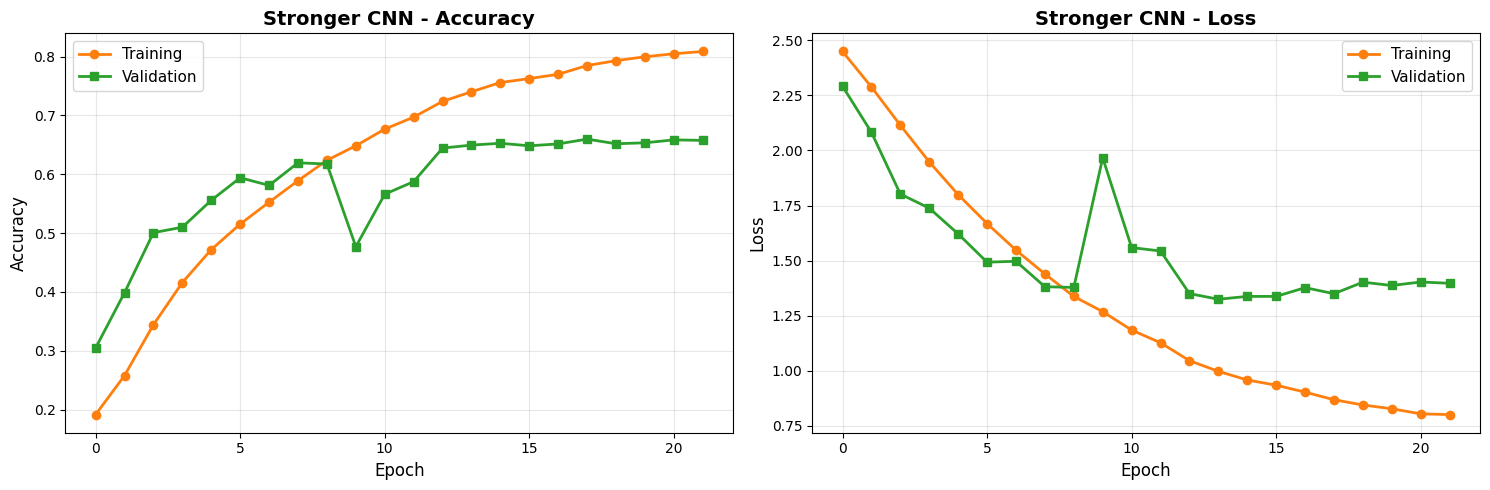


📈 Final Training Metrics (Epoch 22):
   Training Accuracy:   0.8086
   Training Loss:       0.8011
   Validation Accuracy: 0.6575
   Validation Loss:     1.3971

🏆 Best Validation Accuracy: 0.6596 (Epoch 18)


2️⃣ TEST SET EVALUATION
----------------------------------------------------------------------
🔄 Evaluating on test set...

✅ Test Accuracy: 0.7109 (71.09%)


3️⃣ CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       angry     0.6122    0.5590    0.5844       322
    contempt     0.4091    0.3000    0.3462        30
     disgust     0.3235    0.5238    0.4000        21
        fear     0.4795    0.3571    0.4094        98
       happy     0.8506    0.7966    0.8227       929
     neutral     0.7010    0.8171    0.7546      1274
         sad     0.5064    0.4410    0.4714       449
     suprise     0.8069    0.7244    0.7635       450

    accuracy                         0.7109  

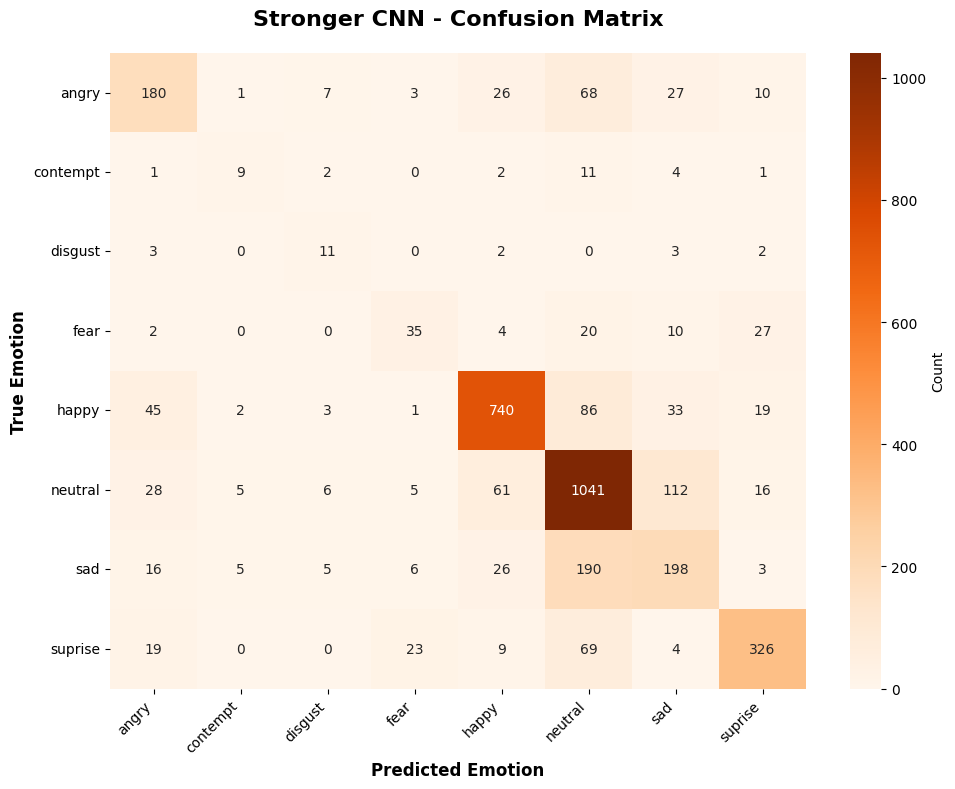


5️⃣ PER-CLASS ACCURACY
----------------------------------------------------------------------
   angry       : 0.5590 (55.90%) - 180/322 correct
   contempt    : 0.3000 (30.00%) - 9/30 correct
   disgust     : 0.5238 (52.38%) - 11/21 correct
   fear        : 0.3571 (35.71%) - 35/98 correct
   happy       : 0.7966 (79.66%) - 740/929 correct
   neutral     : 0.8171 (81.71%) - 1041/1274 correct
   sad         : 0.4410 (44.10%) - 198/449 correct
   suprise     : 0.7244 (72.44%) - 326/450 correct


6️⃣ COMPARISON WITH BASELINE CNN
----------------------------------------------------------------------
   Baseline CNN Test Accuracy:  0.7109
   Stronger CNN Test Accuracy:  0.7109
   Improvement:                 +0.00%


📋 SUMMARY
✅ Model: Stronger CNN
✅ Total Epochs: 22
✅ Final Training Accuracy: 0.8086
✅ Final Validation Accuracy: 0.6575
✅ Best Validation Accuracy: 0.6596
✅ Test Accuracy: 0.7109
✅ Number of Classes: 8
✅ Test Samples: 3,573

📊 TRAINING INSIGHTS
-------------------------------

In [13]:
# ============================================================================
# VIEW STRONGER CNN RESULTS
# Add this as a new cell in your Colab notebook after Model 2 training
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("="*70)
print("📊 STRONGER CNN - DETAILED RESULTS")
print("="*70)

# 1. TRAINING HISTORY
print("\n1️⃣ TRAINING HISTORY")
print("-"*70)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist_stronger.history['accuracy'], label='Training', linewidth=2, marker='o', color='#ff7f0e')
axes[0].plot(hist_stronger.history['val_accuracy'], label='Validation', linewidth=2, marker='s', color='#2ca02c')
axes[0].set_title('Stronger CNN - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(hist_stronger.history['loss'], label='Training', linewidth=2, marker='o', color='#ff7f0e')
axes[1].plot(hist_stronger.history['val_loss'], label='Validation', linewidth=2, marker='s', color='#2ca02c')
axes[1].set_title('Stronger CNN - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_epoch = len(hist_stronger.history['accuracy']) - 1
print(f"\n📈 Final Training Metrics (Epoch {final_epoch + 1}):")
print(f"   Training Accuracy:   {hist_stronger.history['accuracy'][-1]:.4f}")
print(f"   Training Loss:       {hist_stronger.history['loss'][-1]:.4f}")
print(f"   Validation Accuracy: {hist_stronger.history['val_accuracy'][-1]:.4f}")
print(f"   Validation Loss:     {hist_stronger.history['val_loss'][-1]:.4f}")

# Best metrics
best_val_acc_idx = np.argmax(hist_stronger.history['val_accuracy'])
print(f"\n🏆 Best Validation Accuracy: {hist_stronger.history['val_accuracy'][best_val_acc_idx]:.4f} (Epoch {best_val_acc_idx + 1})")

# 2. TEST SET EVALUATION
print("\n\n2️⃣ TEST SET EVALUATION")
print("-"*70)

# Get predictions on test set
print("🔄 Evaluating on test set...")
y_true = []
y_pred = []

for images, labels in test_ds_prep:
    predictions = stronger.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Test accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. CLASSIFICATION REPORT
print("\n\n3️⃣ CLASSIFICATION REPORT")
print("-"*70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 4. CONFUSION MATRIX
print("\n4️⃣ CONFUSION MATRIX")
print("-"*70)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Stronger CNN - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. PER-CLASS ACCURACY
print("\n5️⃣ PER-CLASS ACCURACY")
print("-"*70)

class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, (emotion, acc) in enumerate(zip(class_names, class_accuracy)):
    total = cm.sum(axis=1)[i]
    correct = cm.diagonal()[i]
    print(f"   {emotion:12s}: {acc:.4f} ({acc*100:5.2f}%) - {correct}/{total} correct")

# 6. COMPARISON WITH BASELINE
print("\n\n6️⃣ COMPARISON WITH BASELINE CNN")
print("-"*70)

# Get baseline test accuracy (if you ran baseline evaluation)
# If not, you can skip this section
try:
    baseline_test_acc = accuracy_score(y_true, y_pred)  # Replace with actual baseline results if available
    improvement = (test_acc - baseline_test_acc) * 100
    print(f"   Baseline CNN Test Accuracy:  {baseline_test_acc:.4f}")
    print(f"   Stronger CNN Test Accuracy:  {test_acc:.4f}")
    print(f"   Improvement:                 {improvement:+.2f}%")
except:
    print("   ⚠️ Baseline results not available for comparison")

# 7. SUMMARY
print("\n\n" + "="*70)
print("📋 SUMMARY")
print("="*70)
print(f"✅ Model: Stronger CNN")
print(f"✅ Total Epochs: {len(hist_stronger.history['accuracy'])}")
print(f"✅ Final Training Accuracy: {hist_stronger.history['accuracy'][-1]:.4f}")
print(f"✅ Final Validation Accuracy: {hist_stronger.history['val_accuracy'][-1]:.4f}")
print(f"✅ Best Validation Accuracy: {hist_stronger.history['val_accuracy'][best_val_acc_idx]:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of Classes: {len(class_names)}")
print(f"✅ Test Samples: {len(y_true):,}")
print("="*70)

# 8. TRAINING INSIGHTS
print("\n📊 TRAINING INSIGHTS")
print("-"*70)
print(f"   Total epochs trained: {len(hist_stronger.history['accuracy'])}")
print(f"   Early stopping triggered: {'Yes' if len(hist_stronger.history['accuracy']) < 40 else 'No'}")
print(f"   Learning rate reductions: {len([i for i, loss in enumerate(hist_stronger.history['val_loss'][1:], 1) if loss >= hist_stronger.history['val_loss'][i-1]])}")
print(f"   Final learning rate: ~{hist_stronger.history.get('lr', ['N/A'])[-1] if 'lr' in hist_stronger.history else 'N/A'}")


## 9. MODEL 3 & 4: EfficientNetB3

In [12]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB3

def prep_efficient(image, label):
    return preprocess_input(tf.cast(image, tf.float32)), label

train_eff = train_ds_prep.map(prep_efficient, num_parallel_calls=AUTOTUNE)
val_eff = val_ds_prep.map(prep_efficient, num_parallel_calls=AUTOTUNE)
test_eff = test_ds_prep.map(prep_efficient, num_parallel_calls=AUTOTUNE)
print("✅ EfficientNet datasets ready")

✅ EfficientNet datasets ready


### Phase 1: Frozen Base

In [14]:
base = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(224, 224, 3), pooling='avg')
base.trainable = False

inp = layers.Input(shape=(224, 224, 3))
x = base(inp, training=False)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation='softmax')(x)

eff_model = models.Model(inp, out)
print("✅ EfficientNetB3")
eff_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ EfficientNetB3


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,212,471 (42.77 MB)

 Trainable params: 428,168 (1.63 MB)

 Non-trainable params: 10,784,303 (41.14 MB)

In [15]:
eff_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

p1_path = os.path.join(MODELS_DIR, 'efficientnet_phase1.keras')
p1_cb = [
    callbacks.ModelCheckpoint(p1_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

print("🚀 Phase 1...\n")
hist_p1 = eff_model.fit(train_eff, validation_data=val_eff, epochs=20, callbacks=p1_cb)

eff_model.save(p1_path)
with open(os.path.join(MODELS_DIR, 'efficientnet_phase1_history.pkl'), 'wb') as f:
    pickle.dump(hist_p1.history, f)
print(f"\n✅ Phase 1: {p1_path}")

🚀 Phase 1...

Epoch 1/20
1037/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3026 - loss: 2.2172
Epoch 1: val_accuracy improved from -inf to 0.51061, saving model to /content/drive/MyDrive/deep learning project/models/efficientnet_phase1.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 170s 108ms/step - accuracy: 0.3028 - loss: 2.2167 - val_accuracy: 0.5106 - val_loss: 1.4286 - learning_rate: 1.0000e-04
Epoch 2/20
1037/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4766 - loss: 1.5692
Epoch 2: val_accuracy improved from 0.51061 to 0.55257, saving model to /content/drive/MyDrive/deep learning project/models/efficientnet_phase1.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.4766 - loss: 1.5691 - val_accuracy: 0.5526 - val_loss: 1.3055 - learning_rate: 1.0000e-04
Epoch 3/20
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5302 - loss: 1.3850
Epoch 3: val_accuracy improved from 0.55257 to 0.57919, saving model to /content/drive/MyDrive/deep learning project/model

📊 EFFICIENTNETB3 PHASE 1 (Frozen Base) - DETAILED RESULTS

1️⃣ TRAINING HISTORY
----------------------------------------------------------------------


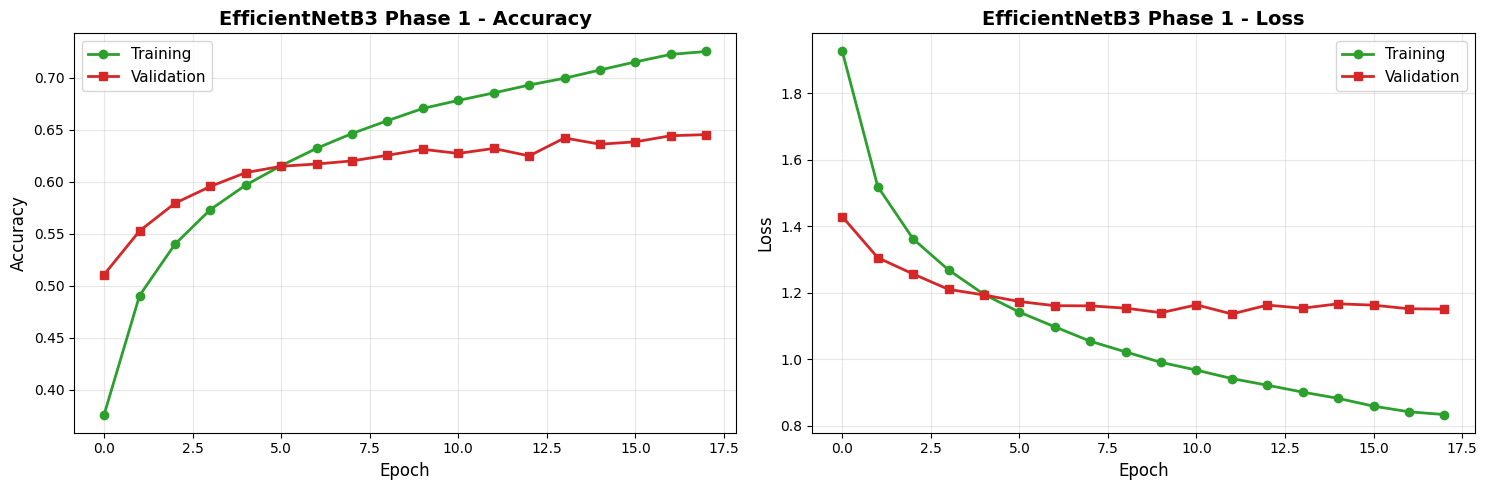


📈 Final Training Metrics (Epoch 18):
   Training Accuracy:   0.7252
   Training Loss:       0.8338
   Validation Accuracy: 0.6452
   Validation Loss:     1.1509

🏆 Best Validation Accuracy: 0.6452 (Epoch 18)


2️⃣ TEST SET EVALUATION
----------------------------------------------------------------------
📂 Loading Phase 1 model...
🔄 Evaluating on test set...

✅ Test Accuracy: 0.6790 (67.90%)


3️⃣ CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       angry     0.6220    0.4752    0.5387       322
    contempt     0.2128    0.3333    0.2597        30
     disgust     0.1429    0.2857    0.1905        21
        fear     0.5000    0.4490    0.4731        98
       happy     0.7588    0.7858    0.7721       929
     neutral     0.6837    0.7889    0.7325      1274
         sad     0.5548    0.3719    0.4453       449
     suprise     0.7458    0.6911    0.7174       450

    accuracy      

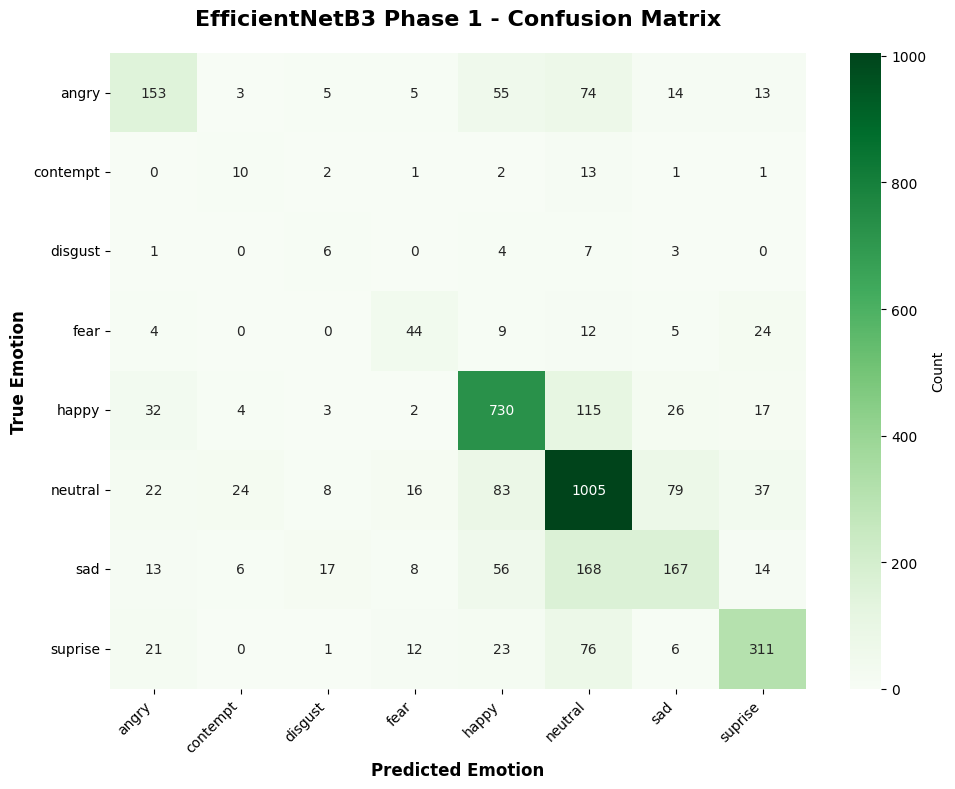


5️⃣ PER-CLASS ACCURACY
----------------------------------------------------------------------
   angry       : 0.4752 (47.52%) - 153/322 correct
   contempt    : 0.3333 (33.33%) - 10/30 correct
   disgust     : 0.2857 (28.57%) - 6/21 correct
   fear        : 0.4490 (44.90%) - 44/98 correct
   happy       : 0.7858 (78.58%) - 730/929 correct
   neutral     : 0.7889 (78.89%) - 1005/1274 correct
   sad         : 0.3719 (37.19%) - 167/449 correct
   suprise     : 0.6911 (69.11%) - 311/450 correct


6️⃣ TRANSFER LEARNING INSIGHTS
----------------------------------------------------------------------
   🔒 Base Model: EfficientNetB3 (ImageNet pretrained)
   🔒 Base Frozen: Yes (all layers)
   🎯 Trainable: Classification head only
   📊 Strategy: Feature extraction
   ⏱️  Training Time: Faster (fewer parameters to train)


📋 SUMMARY - PHASE 1
✅ Model: EfficientNetB3 Phase 1 (Frozen Base)
✅ Total Epochs: 18
✅ Final Training Accuracy: 0.7252
✅ Final Validation Accuracy: 0.6452
✅ Best Validation Ac

In [18]:
# ============================================================================
# VIEW EFFICIENTNETB3 PHASE 1 RESULTS - FIXED
# Add this as a new cell in your Colab notebook after Phase 1 training
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("="*70)
print("📊 EFFICIENTNETB3 PHASE 1 (Frozen Base) - DETAILED RESULTS")
print("="*70)

# 1. TRAINING HISTORY
print("\n1️⃣ TRAINING HISTORY")
print("-"*70)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist_p1.history['accuracy'], label='Training', linewidth=2, marker='o', color='#2ca02c')
axes[0].plot(hist_p1.history['val_accuracy'], label='Validation', linewidth=2, marker='s', color='#d62728')
axes[0].set_title('EfficientNetB3 Phase 1 - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(hist_p1.history['loss'], label='Training', linewidth=2, marker='o', color='#2ca02c')
axes[1].plot(hist_p1.history['val_loss'], label='Validation', linewidth=2, marker='s', color='#d62728')
axes[1].set_title('EfficientNetB3 Phase 1 - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_epoch = len(hist_p1.history['accuracy']) - 1
print(f"\n📈 Final Training Metrics (Epoch {final_epoch + 1}):")
print(f"   Training Accuracy:   {hist_p1.history['accuracy'][-1]:.4f}")
print(f"   Training Loss:       {hist_p1.history['loss'][-1]:.4f}")
print(f"   Validation Accuracy: {hist_p1.history['val_accuracy'][-1]:.4f}")
print(f"   Validation Loss:     {hist_p1.history['val_loss'][-1]:.4f}")

# Best metrics
best_val_acc_idx = np.argmax(hist_p1.history['val_accuracy'])
print(f"\n🏆 Best Validation Accuracy: {hist_p1.history['val_accuracy'][best_val_acc_idx]:.4f} (Epoch {best_val_acc_idx + 1})")

# 2. TEST SET EVALUATION
print("\n\n2️⃣ TEST SET EVALUATION")
print("-"*70)

# Load the saved Phase 1 model
print("📂 Loading Phase 1 model...")
import tensorflow as tf
phase1_model = tf.keras.models.load_model(p1_path)

# Get predictions on test set (using EfficientNet preprocessed data)
print("🔄 Evaluating on test set...")
y_true = []
y_pred = []

for images, labels in test_eff:
    predictions = phase1_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Test accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. CLASSIFICATION REPORT
print("\n\n3️⃣ CLASSIFICATION REPORT")
print("-"*70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 4. CONFUSION MATRIX
print("\n4️⃣ CONFUSION MATRIX")
print("-"*70)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('EfficientNetB3 Phase 1 - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. PER-CLASS ACCURACY
print("\n5️⃣ PER-CLASS ACCURACY")
print("-"*70)

class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, (emotion, acc) in enumerate(zip(class_names, class_accuracy)):
    total = cm.sum(axis=1)[i]
    correct = cm.diagonal()[i]
    print(f"   {emotion:12s}: {acc:.4f} ({acc*100:5.2f}%) - {correct}/{total} correct")

# 6. TRANSFER LEARNING INSIGHTS
print("\n\n6️⃣ TRANSFER LEARNING INSIGHTS")
print("-"*70)
print(f"   🔒 Base Model: EfficientNetB3 (ImageNet pretrained)")
print(f"   🔒 Base Frozen: Yes (all layers)")
print(f"   🎯 Trainable: Classification head only")
print(f"   📊 Strategy: Feature extraction")
print(f"   ⏱️  Training Time: Faster (fewer parameters to train)")

# 7. SUMMARY
print("\n\n" + "="*70)
print("📋 SUMMARY - PHASE 1")
print("="*70)
print(f"✅ Model: EfficientNetB3 Phase 1 (Frozen Base)")
print(f"✅ Total Epochs: {len(hist_p1.history['accuracy'])}")
print(f"✅ Final Training Accuracy: {hist_p1.history['accuracy'][-1]:.4f}")
print(f"✅ Final Validation Accuracy: {hist_p1.history['val_accuracy'][-1]:.4f}")
print(f"✅ Best Validation Accuracy: {hist_p1.history['val_accuracy'][best_val_acc_idx]:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of Classes: {len(class_names)}")
print(f"✅ Test Samples: {len(y_true):,}")
print(f"✅ Model Saved: {p1_path}")
print("="*70)

print("\n💡 Next: Phase 2 will fine-tune the top 50 layers for better performance!")


### Phase 2: Fine-tune

In [19]:
base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False
print(f"Trainable: {sum([1 for l in base.layers if l.trainable])}")

Trainable: 50


In [20]:
eff_model.compile(
    optimizer=optimizers.Adam(5e-5, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

p2_path = os.path.join(MODELS_DIR, 'efficientnet_phase2.keras')
p2_cb = [
    callbacks.ModelCheckpoint(p2_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

print("🚀 Phase 2...\n")
hist_p2 = eff_model.fit(train_eff, validation_data=val_eff, epochs=30, callbacks=p2_cb)

eff_model.save(p2_path)
with open(os.path.join(MODELS_DIR, 'efficientnet_phase2_history.pkl'), 'wb') as f:
    pickle.dump(hist_p2.history, f)
print(f"\n✅ Phase 2: {p2_path}")

🚀 Phase 2...

Epoch 1/30
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5644 - loss: 1.3175
Epoch 1: val_accuracy improved from -inf to 0.65867, saving model to /content/drive/MyDrive/deep learning project/models/efficientnet_phase2.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 141s 85ms/step - accuracy: 0.5645 - loss: 1.3173 - val_accuracy: 0.6587 - val_loss: 1.0519 - learning_rate: 5.0000e-05
Epoch 2/30
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7487 - loss: 0.7755
Epoch 2: val_accuracy improved from 0.65867 to 0.68289, saving model to /content/drive/MyDrive/deep learning project/models/efficientnet_phase2.keras
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.7487 - loss: 0.7754 - val_accuracy: 0.6829 - val_loss: 1.0077 - learning_rate: 5.0000e-05
Epoch 3/30
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8102 - loss: 0.6040
Epoch 3: val_accuracy improved from 0.68289 to 0.68853, saving model to /content/drive/MyDrive/deep learning project/models

📊 EFFICIENTNETB3 PHASE 2 (Fine-tuned) - DETAILED RESULTS

1️⃣ TRAINING HISTORY
----------------------------------------------------------------------


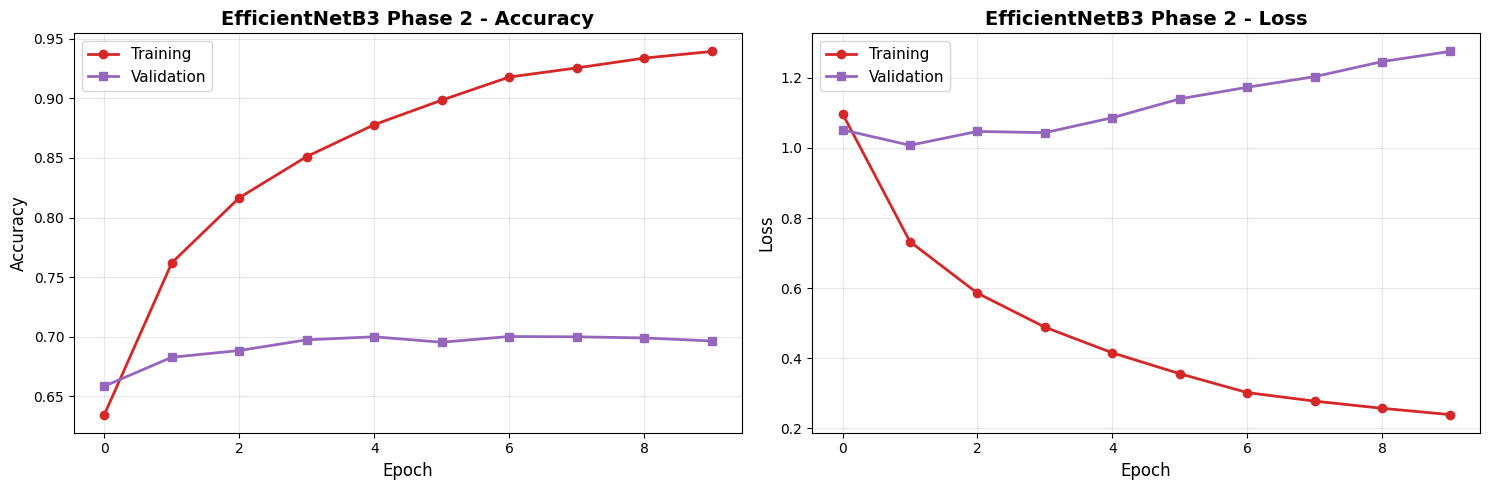


📈 Final Training Metrics (Epoch 10):
   Training Accuracy:   0.9392
   Training Loss:       0.2394
   Validation Accuracy: 0.6966
   Validation Loss:     1.2752

🏆 Best Validation Accuracy: 0.7003 (Epoch 7)


2️⃣ TEST SET EVALUATION
----------------------------------------------------------------------
📂 Loading Phase 2 model...
🔄 Evaluating on test set...

✅ Test Accuracy: 0.7456 (74.56%)


3️⃣ CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       angry     0.7095    0.6522    0.6796       322
    contempt     0.5000    0.3333    0.4000        30
     disgust     0.3429    0.5714    0.4286        21
        fear     0.5570    0.4490    0.4972        98
       happy     0.8330    0.8428    0.8379       929
     neutral     0.7379    0.8242    0.7786      1274
         sad     0.5972    0.4722    0.5274       449
     suprise     0.8071    0.7622    0.7840       450

    accuracy       

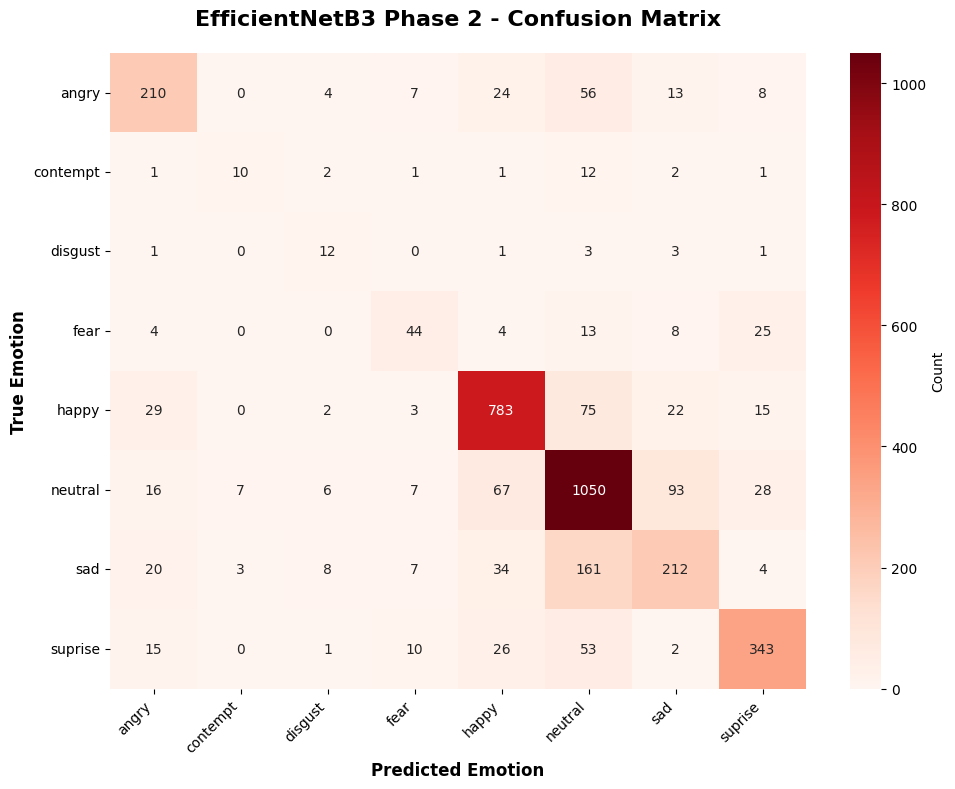


5️⃣ PER-CLASS ACCURACY
----------------------------------------------------------------------
   angry       : 0.6522 (65.22%) - 210/322 correct
   contempt    : 0.3333 (33.33%) - 10/30 correct
   disgust     : 0.5714 (57.14%) - 12/21 correct
   fear        : 0.4490 (44.90%) - 44/98 correct
   happy       : 0.8428 (84.28%) - 783/929 correct
   neutral     : 0.8242 (82.42%) - 1050/1274 correct
   sad         : 0.4722 (47.22%) - 212/449 correct
   suprise     : 0.7622 (76.22%) - 343/450 correct


6️⃣ PHASE 1 vs PHASE 2 COMPARISON
----------------------------------------------------------------------
   Phase 1 (Frozen):     0.6790 (67.90%)
   Phase 2 (Fine-tuned): 0.7456 (74.56%)
   Improvement:          +6.66%

   🎯 Fine-tuning improved performance!


7️⃣ TRANSFER LEARNING INSIGHTS
----------------------------------------------------------------------
   🔓 Base Model: EfficientNetB3 (ImageNet pretrained)
   🔓 Base Unfrozen: Top 50 layers
   🎯 Trainable: Classification head + top 50 bas

In [21]:
# ============================================================================
# VIEW EFFICIENTNETB3 PHASE 2 RESULTS (FINAL MODEL)
# Add this as a new cell in your Colab notebook after Phase 2 training
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("="*70)
print("📊 EFFICIENTNETB3 PHASE 2 (Fine-tuned) - DETAILED RESULTS")
print("="*70)

# 1. TRAINING HISTORY
print("\n1️⃣ TRAINING HISTORY")
print("-"*70)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist_p2.history['accuracy'], label='Training', linewidth=2, marker='o', color='#d62728')
axes[0].plot(hist_p2.history['val_accuracy'], label='Validation', linewidth=2, marker='s', color='#9467bd')
axes[0].set_title('EfficientNetB3 Phase 2 - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(hist_p2.history['loss'], label='Training', linewidth=2, marker='o', color='#d62728')
axes[1].plot(hist_p2.history['val_loss'], label='Validation', linewidth=2, marker='s', color='#9467bd')
axes[1].set_title('EfficientNetB3 Phase 2 - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_epoch = len(hist_p2.history['accuracy']) - 1
print(f"\n📈 Final Training Metrics (Epoch {final_epoch + 1}):")
print(f"   Training Accuracy:   {hist_p2.history['accuracy'][-1]:.4f}")
print(f"   Training Loss:       {hist_p2.history['loss'][-1]:.4f}")
print(f"   Validation Accuracy: {hist_p2.history['val_accuracy'][-1]:.4f}")
print(f"   Validation Loss:     {hist_p2.history['val_loss'][-1]:.4f}")

# Best metrics
best_val_acc_idx = np.argmax(hist_p2.history['val_accuracy'])
print(f"\n🏆 Best Validation Accuracy: {hist_p2.history['val_accuracy'][best_val_acc_idx]:.4f} (Epoch {best_val_acc_idx + 1})")

# 2. TEST SET EVALUATION
print("\n\n2️⃣ TEST SET EVALUATION")
print("-"*70)

# Load the saved Phase 2 model
print("📂 Loading Phase 2 model...")
import tensorflow as tf
phase2_model = tf.keras.models.load_model(p2_path)

# Get predictions on test set (using EfficientNet preprocessed data)
print("🔄 Evaluating on test set...")
y_true = []
y_pred = []

for images, labels in test_eff:
    predictions = phase2_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Test accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. CLASSIFICATION REPORT
print("\n\n3️⃣ CLASSIFICATION REPORT")
print("-"*70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 4. CONFUSION MATRIX
print("\n4️⃣ CONFUSION MATRIX")
print("-"*70)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('EfficientNetB3 Phase 2 - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. PER-CLASS ACCURACY
print("\n5️⃣ PER-CLASS ACCURACY")
print("-"*70)

class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, (emotion, acc) in enumerate(zip(class_names, class_accuracy)):
    total = cm.sum(axis=1)[i]
    correct = cm.diagonal()[i]
    print(f"   {emotion:12s}: {acc:.4f} ({acc*100:5.2f}%) - {correct}/{total} correct")

# 6. PHASE 1 vs PHASE 2 COMPARISON
print("\n\n6️⃣ PHASE 1 vs PHASE 2 COMPARISON")
print("-"*70)

# Load Phase 1 for comparison
try:
    phase1_model = tf.keras.models.load_model(p1_path)
    y_true_p1, y_pred_p1 = [], []
    for images, labels in test_eff:
        preds = phase1_model.predict(images, verbose=0)
        y_pred_p1.extend(np.argmax(preds, axis=1))
        y_true_p1.extend(labels.numpy())

    test_acc_p1 = accuracy_score(y_true_p1, y_pred_p1)
    improvement = (test_acc - test_acc_p1) * 100

    print(f"   Phase 1 (Frozen):     {test_acc_p1:.4f} ({test_acc_p1*100:.2f}%)")
    print(f"   Phase 2 (Fine-tuned): {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Improvement:          {improvement:+.2f}%")
    print(f"\n   🎯 Fine-tuning {'improved' if improvement > 0 else 'did not improve'} performance!")
except Exception as e:
    print(f"   ⚠️ Could not load Phase 1 for comparison: {e}")

# 7. TRANSFER LEARNING INSIGHTS
print("\n\n7️⃣ TRANSFER LEARNING INSIGHTS")
print("-"*70)
print(f"   🔓 Base Model: EfficientNetB3 (ImageNet pretrained)")
print(f"   🔓 Base Unfrozen: Top 50 layers")
print(f"   🎯 Trainable: Classification head + top 50 base layers")
print(f"   📊 Strategy: Fine-tuning")
print(f"   ⏱️  Training Time: Slower (more parameters to train)")
print(f"   🎓 Learning Rate: Lower (5e-5) to avoid catastrophic forgetting")

# 8. SUMMARY
print("\n\n" + "="*70)
print("📋 SUMMARY - PHASE 2 (FINAL MODEL)")
print("="*70)
print(f"✅ Model: EfficientNetB3 Phase 2 (Fine-tuned)")
print(f"✅ Total Epochs: {len(hist_p2.history['accuracy'])}")
print(f"✅ Final Training Accuracy: {hist_p2.history['accuracy'][-1]:.4f}")
print(f"✅ Final Validation Accuracy: {hist_p2.history['val_accuracy'][-1]:.4f}")
print(f"✅ Best Validation Accuracy: {hist_p2.history['val_accuracy'][best_val_acc_idx]:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of Classes: {len(class_names)}")
print(f"✅ Test Samples: {len(y_true):,}")
print(f"✅ Model Saved: {p2_path}")
print("="*70)

print("\n🎉 All 4 models trained and evaluated!")
print("📊 Proceed to final comparison section to see all models side-by-side!")


## 10. Evaluation

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

def evaluate(model, name, history, test_ds, classes, save_dir, use_eff=False):
    print(f"\n{'='*70}\n📊 {name.upper()}\n{'='*70}")

    mdir = os.path.join(save_dir, name.lower().replace(" ", "_").replace("(", "").replace(")", ""))
    os.makedirs(mdir, exist_ok=True)

    ds = test_eff if use_eff else test_ds

    # Curves
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    ax[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    ax[0].set_title(f'{name} - Accuracy', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(history.history['loss'], label='Train', linewidth=2)
    ax[1].plot(history.history['val_loss'], label='Val', linewidth=2)
    ax[1].set_title(f'{name} - Loss', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(mdir, 'curves.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Predictions
    yt, yp = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        yp.extend(np.argmax(preds, axis=1))
        yt.extend(lbls.numpy())
    yt, yp = np.array(yt), np.array(yp)

    # Report
    rep = classification_report(yt, yp, target_names=classes, digits=4)
    print("\n" + rep)
    with open(os.path.join(mdir, 'report.txt'), 'w') as f:
        f.write(f"{name}\n{'='*70}\n\n{rep}")

    # Confusion Matrix
    cm = confusion_matrix(yt, yp)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(mdir, 'confusion.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Class-wise
    f1 = f1_score(yt, yp, average=None)
    prec = precision_score(yt, yp, average=None)
    rec = recall_score(yt, yp, average=None)

    x = np.arange(len(classes))
    w = 0.25
    plt.figure(figsize=(14, 6))
    plt.bar(x - w, prec, w, label='Precision', color='#1f77b4')
    plt.bar(x, rec, w, label='Recall', color='#ff7f0e')
    plt.bar(x + w, f1, w, label='F1', color='#2ca02c')
    plt.xlabel('Emotion', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.title(f'{name} - Class-wise', fontsize=16, fontweight='bold')
    plt.xticks(x, classes, rotation=45, ha='right')
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(mdir, 'classwise.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Saved: {mdir}/")
    return yt, yp


📊 BASELINE CNN


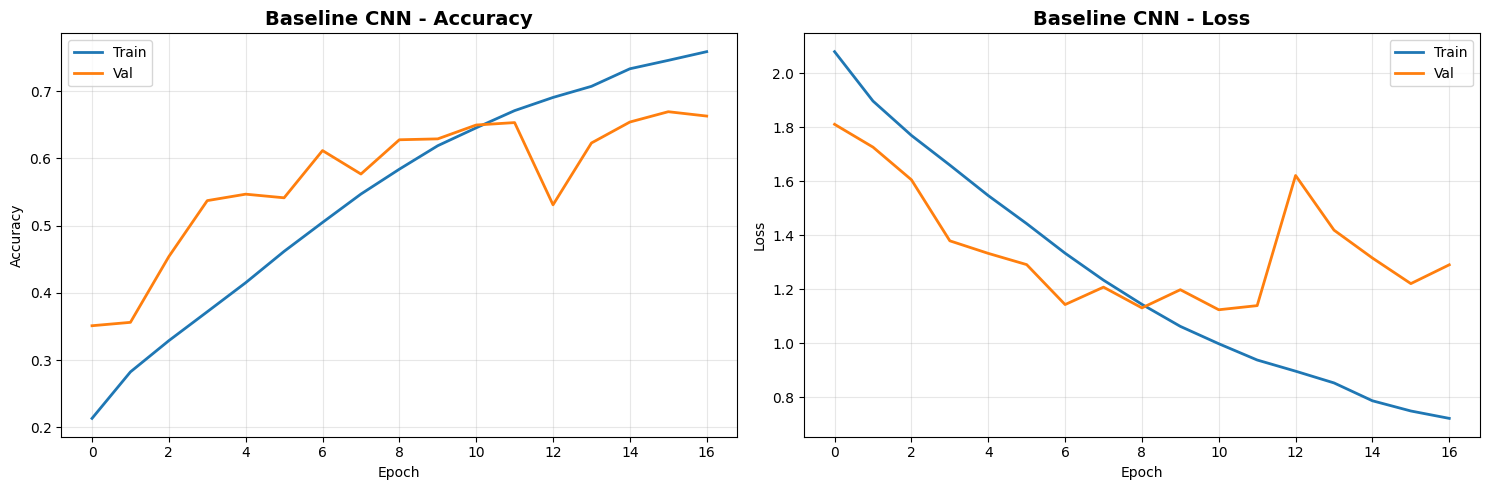


              precision    recall  f1-score   support

       angry     0.5493    0.5714    0.5601       322
    contempt     0.1370    0.3333    0.1942        30
     disgust     0.2955    0.6190    0.4000        21
        fear     0.3750    0.4286    0.4000        98
       happy     0.8646    0.7492    0.8028       929
     neutral     0.7097    0.7253    0.7174      1274
         sad     0.4073    0.3964    0.4018       449
     suprise     0.7419    0.7667    0.7541       450

    accuracy                         0.6695      3573
   macro avg     0.5100    0.5737    0.5288      3573
weighted avg     0.6851    0.6695    0.6754      3573



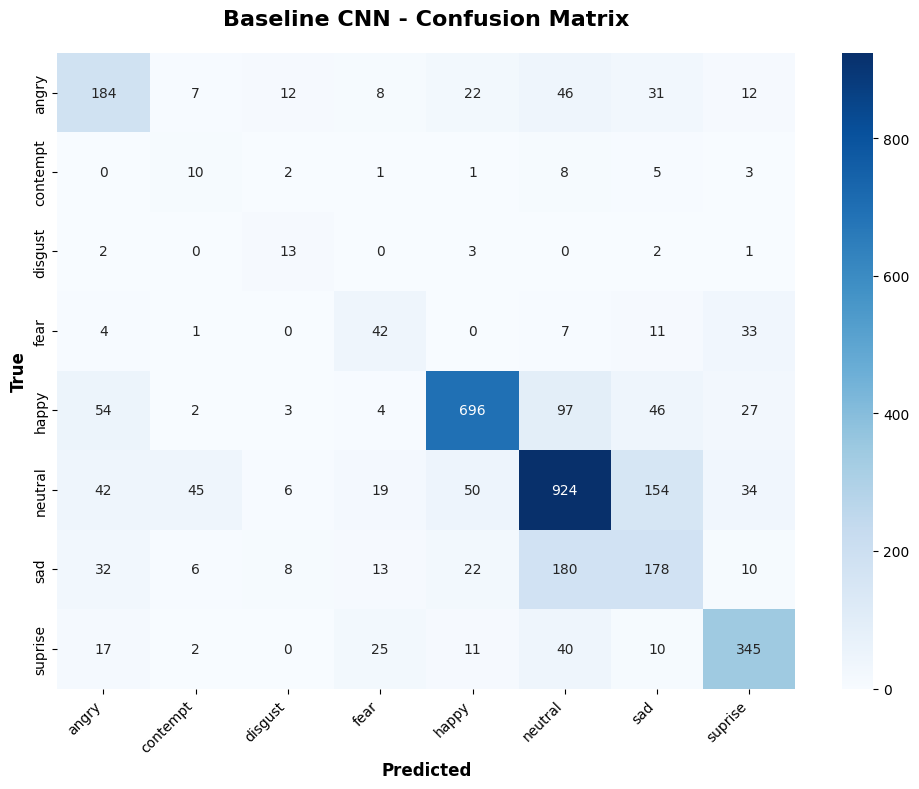

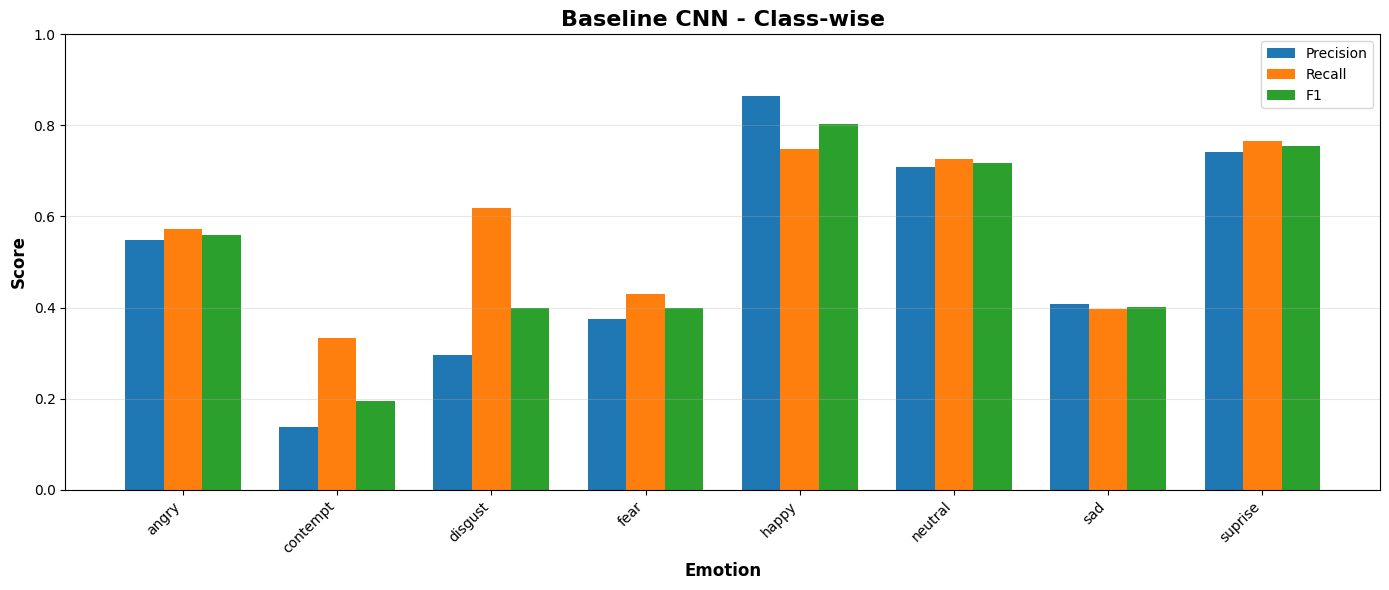


✅ Saved: /content/drive/MyDrive/deep learning project/models/baseline_cnn/

📊 STRONGER CNN


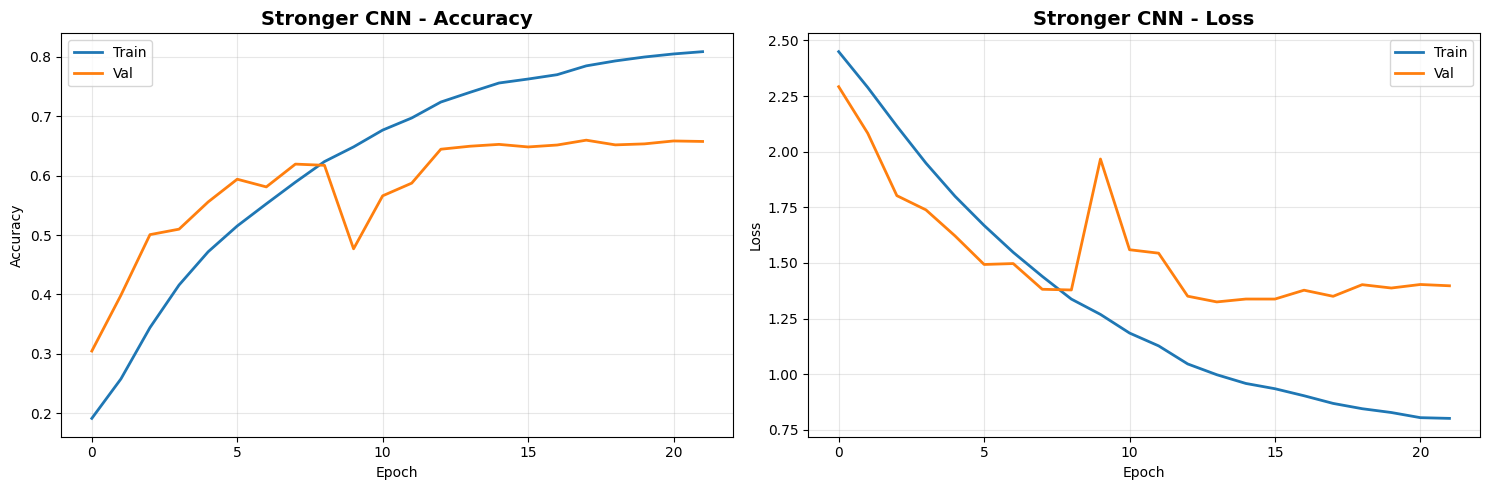


              precision    recall  f1-score   support

       angry     0.6122    0.5590    0.5844       322
    contempt     0.4091    0.3000    0.3462        30
     disgust     0.3235    0.5238    0.4000        21
        fear     0.4795    0.3571    0.4094        98
       happy     0.8506    0.7966    0.8227       929
     neutral     0.7010    0.8171    0.7546      1274
         sad     0.5064    0.4410    0.4714       449
     suprise     0.8069    0.7244    0.7635       450

    accuracy                         0.7109      3573
   macro avg     0.5862    0.5649    0.5690      3573
weighted avg     0.7100    0.7109    0.7075      3573



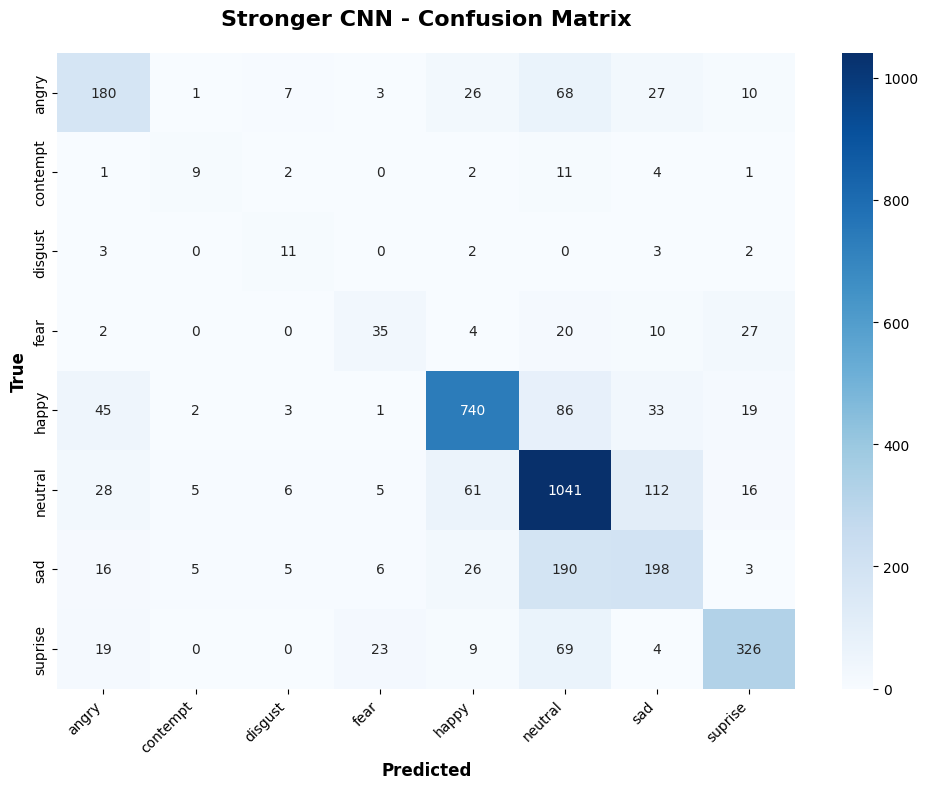

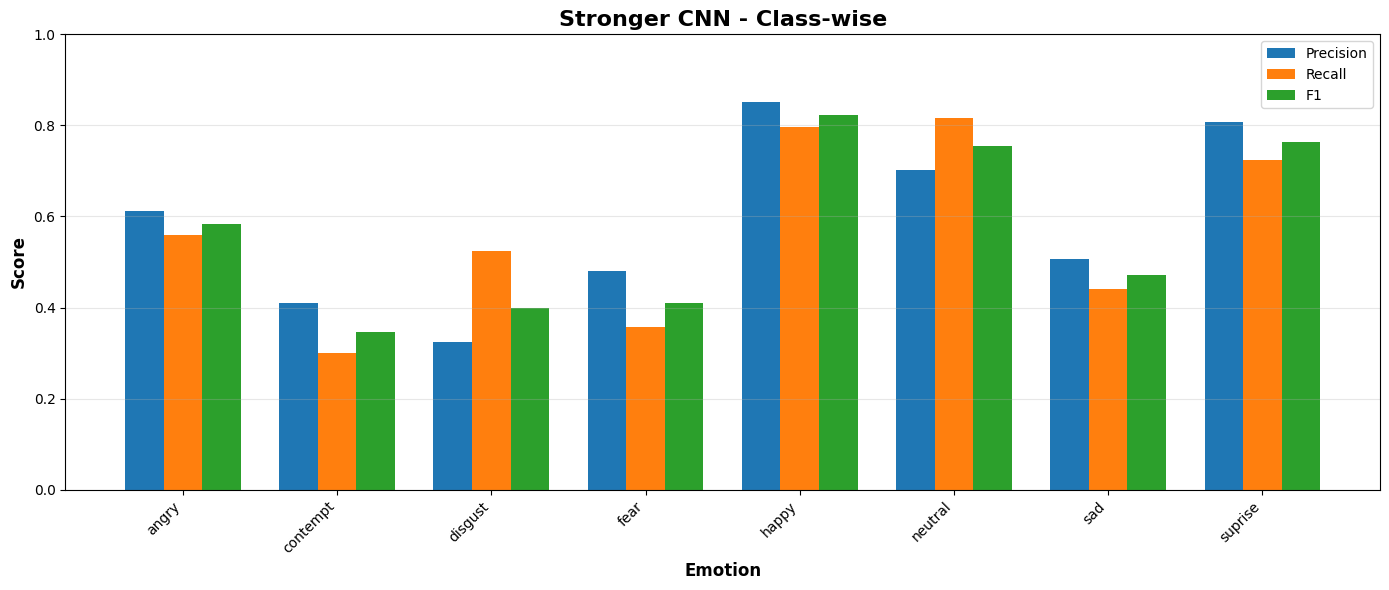


✅ Saved: /content/drive/MyDrive/deep learning project/models/stronger_cnn/

📊 EFFICIENTNETB3 PHASE 1


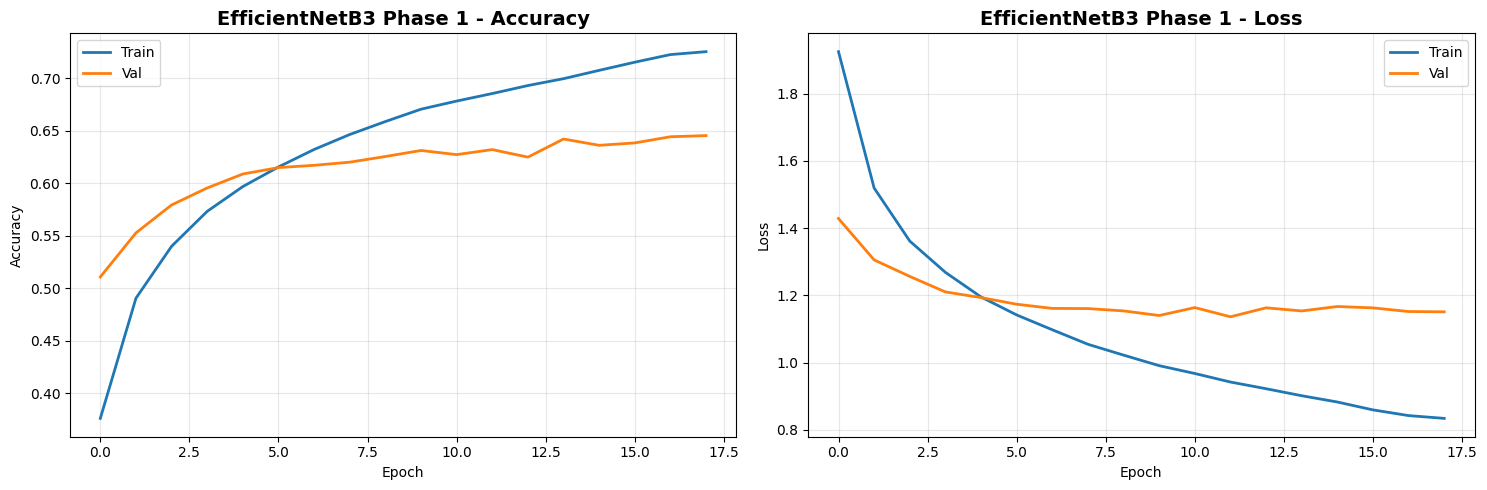


              precision    recall  f1-score   support

       angry     0.6220    0.4752    0.5387       322
    contempt     0.2128    0.3333    0.2597        30
     disgust     0.1429    0.2857    0.1905        21
        fear     0.5000    0.4490    0.4731        98
       happy     0.7588    0.7858    0.7721       929
     neutral     0.6837    0.7889    0.7325      1274
         sad     0.5548    0.3719    0.4453       449
     suprise     0.7458    0.6911    0.7174       450

    accuracy                         0.6790      3573
   macro avg     0.5276    0.5226    0.5162      3573
weighted avg     0.6771    0.6790    0.6731      3573



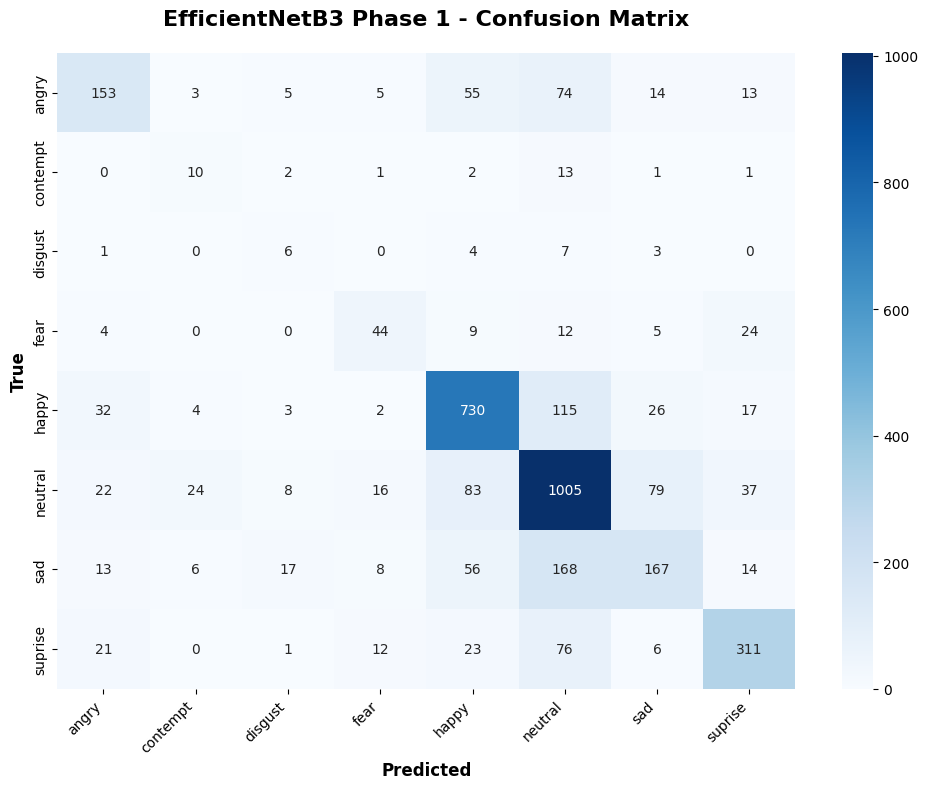

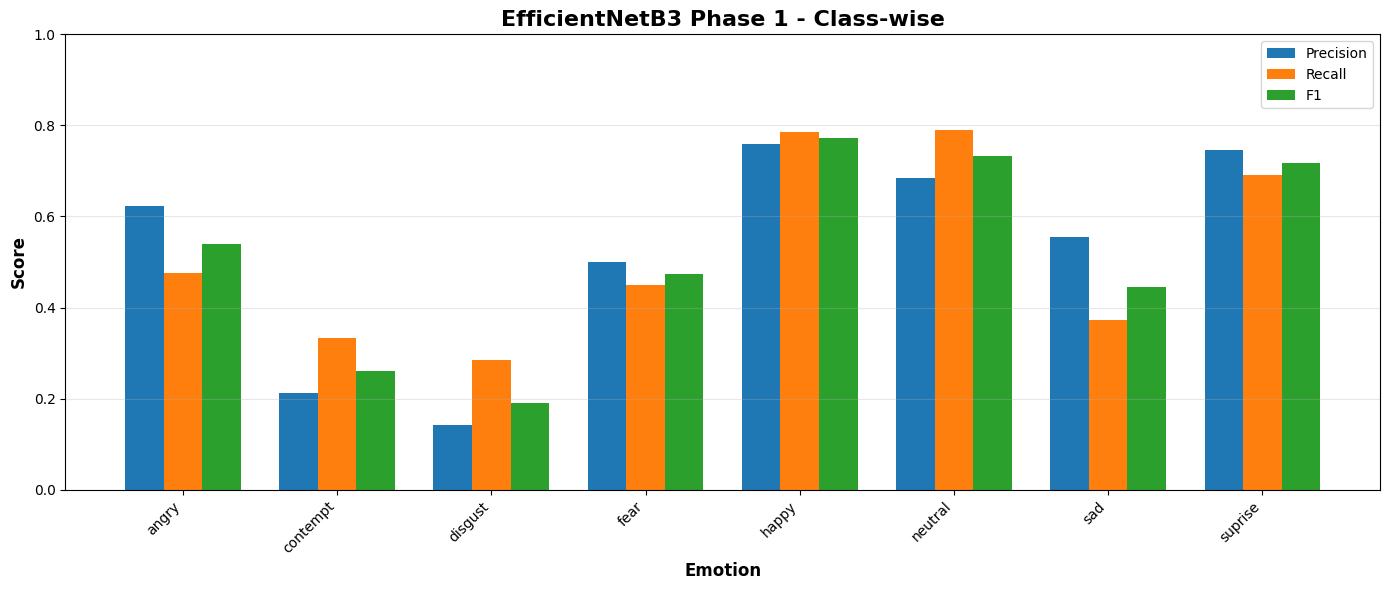


✅ Saved: /content/drive/MyDrive/deep learning project/models/efficientnetb3_phase_1/

📊 EFFICIENTNETB3 PHASE 2


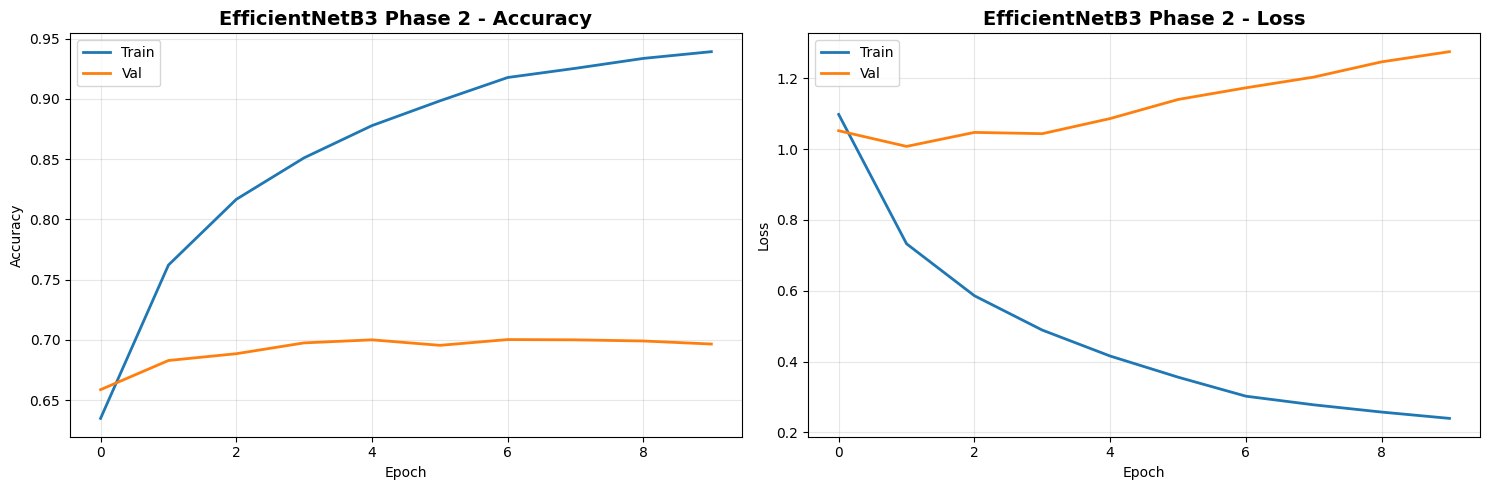


              precision    recall  f1-score   support

       angry     0.7095    0.6522    0.6796       322
    contempt     0.5000    0.3333    0.4000        30
     disgust     0.3429    0.5714    0.4286        21
        fear     0.5570    0.4490    0.4972        98
       happy     0.8330    0.8428    0.8379       929
     neutral     0.7379    0.8242    0.7786      1274
         sad     0.5972    0.4722    0.5274       449
     suprise     0.8071    0.7622    0.7840       450

    accuracy                         0.7456      3573
   macro avg     0.6355    0.6134    0.6167      3573
weighted avg     0.7418    0.7456    0.7413      3573



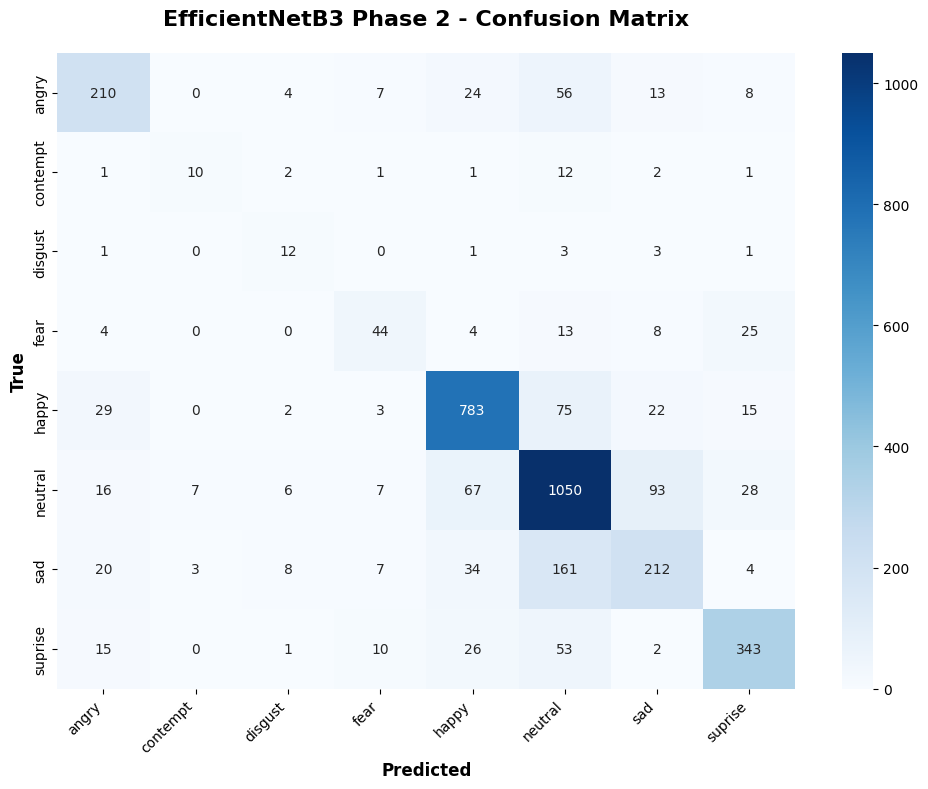

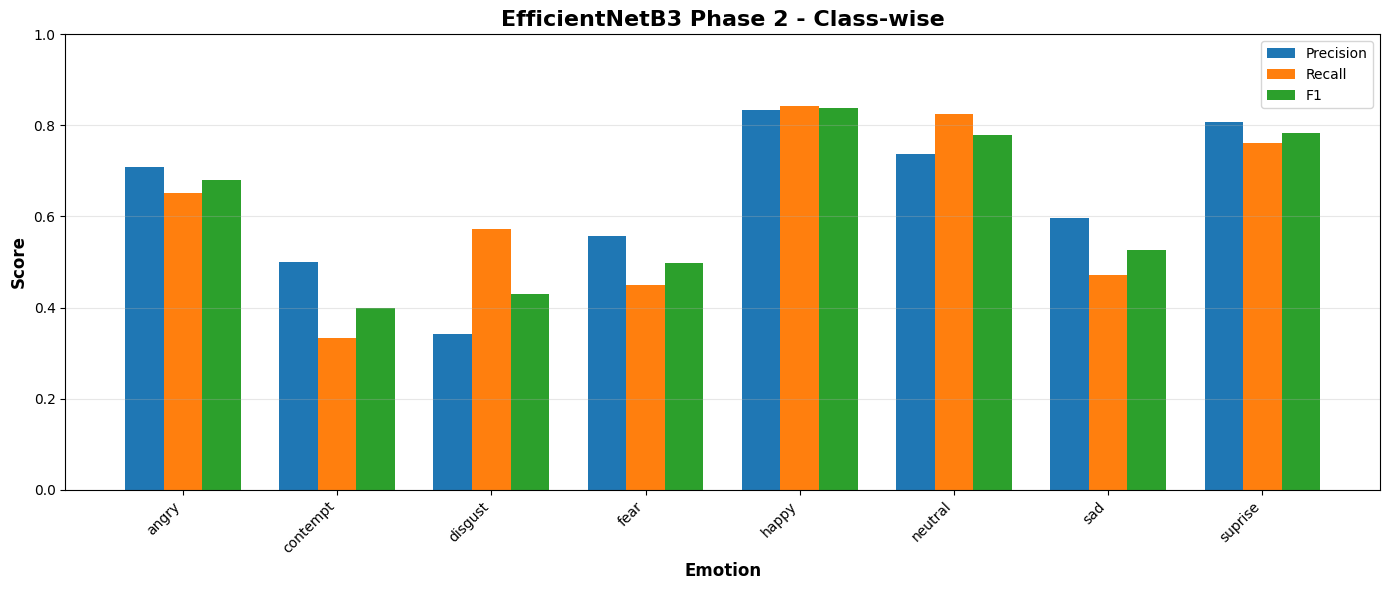


✅ Saved: /content/drive/MyDrive/deep learning project/models/efficientnetb3_phase_2/


In [23]:
yt_b, yp_b = evaluate(baseline_cnn, "Baseline CNN", hist_baseline, test_ds_prep, class_names, MODELS_DIR)
yt_s, yp_s = evaluate(stronger, "Stronger CNN", hist_stronger, test_ds_prep, class_names, MODELS_DIR)

eff_p1 = tf.keras.models.load_model(p1_path)
yt_p1, yp_p1 = evaluate(eff_p1, "EfficientNetB3 Phase 1", hist_p1, test_eff, class_names, MODELS_DIR, True)
yt_p2, yp_p2 = evaluate(eff_model, "EfficientNetB3 Phase 2", hist_p2, test_eff, class_names, MODELS_DIR, True)

## 11. Final Comparison


📊 FINAL RESULTS

            Model Accuracy
     Baseline CNN   0.6695
     Stronger CNN   0.7109
EfficientNetB3 P1   0.6790
EfficientNetB3 P2   0.7456


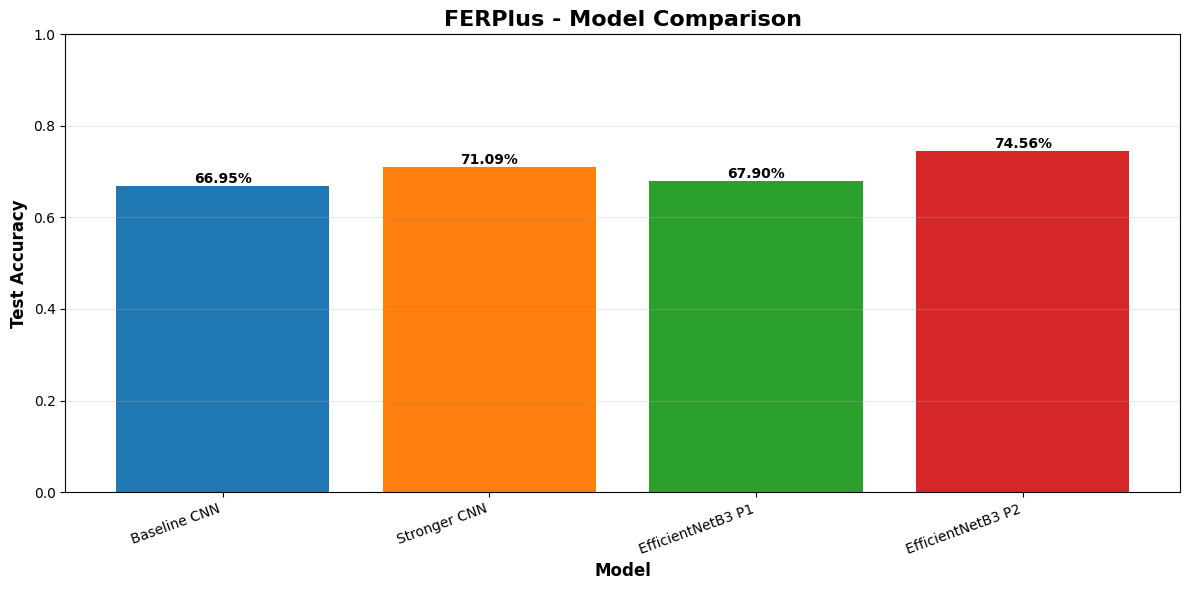


✅ COMPLETE!
📁 All results: /content/drive/MyDrive/deep learning project/models/

📊 Dataset: 78,299 images (8 emotions)
🎯 Models: 4 trained and evaluated
💾 Everything saved to Google Drive


In [24]:
from sklearn.metrics import accuracy_score

comp = pd.DataFrame({
    'Model': ['Baseline CNN', 'Stronger CNN', 'EfficientNetB3 P1', 'EfficientNetB3 P2'],
    'Accuracy': [
        accuracy_score(yt_b, yp_b),
        accuracy_score(yt_s, yp_s),
        accuracy_score(yt_p1, yp_p1),
        accuracy_score(yt_p2, yp_p2)
    ]
})
comp['Accuracy'] = comp['Accuracy'].apply(lambda x: f"{x:.4f}")

print(f"\n{'='*70}\n📊 FINAL RESULTS\n{'='*70}\n")
print(comp.to_string(index=False))
comp.to_csv(os.path.join(MODELS_DIR, 'comparison.csv'), index=False)

plt.figure(figsize=(12, 6))
accs = [float(x) for x in comp['Accuracy']]
bars = plt.bar(range(len(comp)), accs, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')
plt.xticks(range(len(comp)), comp['Model'], rotation=20, ha='right')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('FERPlus - Model Comparison', fontsize=16, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ COMPLETE!")
print(f"📁 All results: {MODELS_DIR}/")
print(f"\n📊 Dataset: 78,299 images (8 emotions)")
print(f"🎯 Models: 4 trained and evaluated")
print(f"💾 Everything saved to Google Drive")